In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import numpy as np

In [7]:
data = pd.DataFrame()

data["Ratings"] = ["AAA","AA+","AA", "AA-","A+","A","A-","BBB+","BBB","BBB-","BB+",
                   "BB","BB-","B+","B","B-","CCC"]
data ["Lambda (%)"] = [ 0.0300045009001992, 0.0393572941140666,0.0300045009001992, 0.0378047766020941,
                   0.0476333744497823, 0.0600180072032461, 0.0865724373412873,0.124882975720625,0.180162194662821,
                   0.286141183044645, 0.454603334863285, 0.722604509173958,1.25702626200087,2.19104774517194,
                   3.83251143216679, 10.5744814051576,31.1701578296001]

In [8]:
def hazard_rate(t,adj_factor):
    
    for i in range(1,1500):
        data[i] = 1- (np.exp(-((data["Lambda (%)"])/100)*i))
    
    data_updated = data[["Ratings", "Lambda (%)"]]
    data_updated ["Lambda (%)"] = data_updated["Lambda (%)"] * adj_factor


    for i in range(1,t+1):
        data_updated[i] = 1- (np.exp(-((data_updated["Lambda (%)"]/100)*i)))
        
    data_diff = data_updated[["Ratings","Lambda (%)"]]

    for i in range(1,t):
        data_diff[i] = data_updated[i] - data[i]
    
    fig, axes = plt.subplots(2,2, figsize =(20,15))

    # 1st Plot : 

    years = list(range(1,t))
    plot_data = data[["Ratings"] + years]

    plot_data_t = plot_data.set_index("Ratings").T

    plt.figure(figsize = (30,15))

    selected_ratings = plot_data_t.columns
    selected_ratings
    for rating in selected_ratings:
        axes[0,0].plot(plot_data_t.index, plot_data_t[rating], label = rating, linewidth =2)
    
    axes[0,0].set_title ("Probability of Default term structure")
    axes[0,0].set_xlabel ("Years", fontsize = 12)
    axes[0,0].set_ylabel("PD")

    # 2nd plot:  

    plot_data = data_updated[["Ratings"] + years]
    plot_data_t = plot_data.set_index("Ratings").T

    selected_ratings = plot_data_t.columns

    for rating in selected_ratings:
        axes[0,1].plot(plot_data_t.index, plot_data_t[rating], label = rating, linewidth =2)

    axes[0,1].set_title("Probability of Default - Updated values")
    axes[0,1].set_xlabel("Years", fontsize = 12)
    axes[0,1].set_ylabel("PD", fontsize =12)

    # 3rd plot : 
    plot_data = data_diff[['Ratings'] + years]
    plot_data_t = plot_data.set_index('Ratings').T # transposing the data.

    selected_ratings = plot_data_t.columns

    for rating in selected_ratings:
        axes[1,0].plot(plot_data_t.index, plot_data_t[rating], label=rating, linewidth=2)

    axes[1,0].set_title("Difference in Probability of Default by Rating Grade when the adj_factor is "f'{adj_factor}', fontsize=14)
    axes[1,0].set_xlabel("Years", fontsize=12)
    axes[1,0].set_ylabel("Difference in Probability of Default", fontsize=12)
    axes[1,0].grid(alpha=0.3)
    axes[1, 1].axis('off')

    handles, labels = axes[0,0].get_legend_handles_labels()
    axes[1,1].legend(handles, labels, loc='upper left', title="Ratings", ncol=3, fontsize=12)
    axes[1,1].axis('off')
    plt.show()

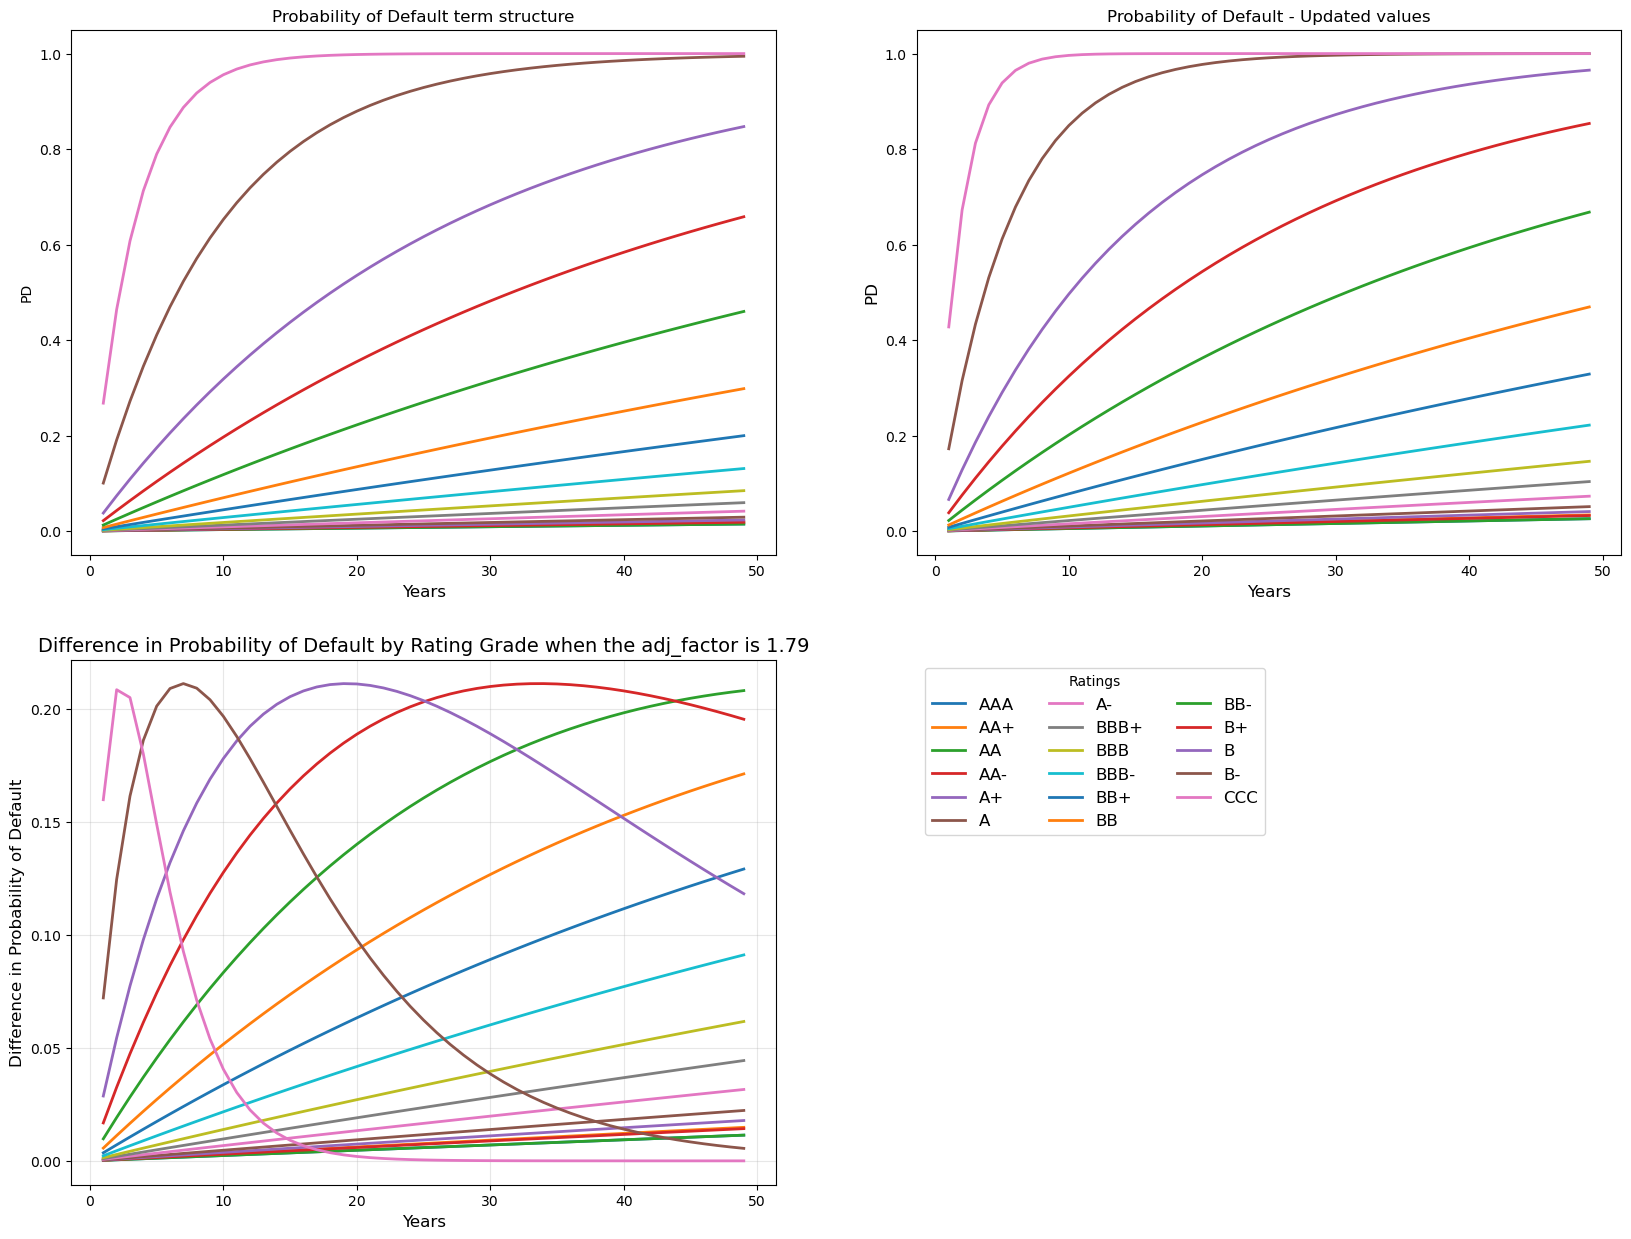

<Figure size 3000x1500 with 0 Axes>

In [9]:
hazard_rate(50,1.79)  # First parameter is time (in years) and the second parameter is the adj_factor